In [ ]:
!pip install -q paddlepaddle==3.2.0
!pip install -q paddleocr
!pip install -q opencv-python-headless rapidfuzz pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.0/189.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7

In [ ]:
import os
import zipfile
import requests

url = "https://www.crc.nd.edu/~pmoreira/funsd.zip"
zip_path = "/content/funsd.zip"

r = requests.get(url)
open(zip_path, "wb").write(r.content)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content/funsd")

print("Dataset downloaded!")

Dataset downloaded!


In [ ]:
!find /content/funsd -type f | head -20

/content/funsd/FUNSD/testing_data/.DS_Store
/content/funsd/FUNSD/testing_data/annotations/89856243.json
/content/funsd/FUNSD/testing_data/annotations/82200067_0069.json
/content/funsd/FUNSD/testing_data/annotations/82837252.json
/content/funsd/FUNSD/testing_data/annotations/85629964.json
/content/funsd/FUNSD/testing_data/annotations/85240939.json
/content/funsd/FUNSD/testing_data/annotations/83443897.json
/content/funsd/FUNSD/testing_data/annotations/83594639.json
/content/funsd/FUNSD/testing_data/annotations/86075409_5410.json
/content/funsd/FUNSD/testing_data/annotations/87428306.json
/content/funsd/FUNSD/testing_data/annotations/87528321.json
/content/funsd/FUNSD/testing_data/annotations/87086073.json
/content/funsd/FUNSD/testing_data/annotations/86244113.json
/content/funsd/FUNSD/testing_data/annotations/85201976.json
/content/funsd/FUNSD/testing_data/annotations/87332450.json
/content/funsd/FUNSD/testing_data/annotations/82254765.json
/content/funsd/FUNSD/testing_data/annotations/

In [ ]:
import os
import json
import glob

# Find image directory automatically
image_files = glob.glob(
    "/content/funsd/**/images/*.png",
    recursive=True
)

json_files = glob.glob(
    "/content/funsd/**/annotations/*.json",
    recursive=True
)

print("Images:", len(image_files))
print("Annotations:", len(json_files))

# Create mapping from filename -> annotation
annotation_map = {}

for jf in json_files:
    with open(jf, "r", encoding="utf-8") as f:
        data = json.load(f)

    annotation_map[os.path.basename(jf)] = data

print("Annotations loaded:", len(annotation_map))

Images: 199
Annotations: 199
Annotations loaded: 199


In [ ]:
def get_ground_truth(json_data):
    words = []

    for entity in json_data["form"]:
        for word in entity.get("words", []):
            text = word.get("text", "").strip()

            if text:
                words.append(text)

    return " ".join(words)

In [ ]:
sample_json = list(annotation_map.values())[0]

gt = get_ground_truth(sample_json)

print(gt[:1000])

file PRODUCT Date Triumph yes yes no no Approved by: Incidence - 4 1 Topline Final 89856243 Marketing Research Director October 17, 1979 MARKETING RESEARCH RPROJECT APPROVAL (To be filled out by Marketing Research Department) PROJECT TITLE Triumph Disaster Check Study 5546/ 1979 Research Design (N, Cells, Elegibility, Design, Key Danner Breaks, Methodololy, Cities) Contact respondents from Buffalo and Kansas City who had previously participated in a steak knife offer This will consist of one cell of approximately 175 respondents who are Triumph most often smokers /triers This study is intended to provide us with any negatives associated with Triumph Banner points will include Triumph most often smokers (we anticipate approximately 25 most of ten people Switchers away from Triumph (N approximately 45). It should be noted that an action standard of at least 50% be obtained in acting upon any product negatives associated with these groups see research limitations below for additional acti

In [ ]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    engine="paddle"
)

print("OCR ready!")

/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_det', None, 'paddle')
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, 'paddle')
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

OCR ready!


## OCR FUNCTION

In [ ]:
def run_ocr(image_path):

    result = ocr.predict(image_path)

    texts = []

    for res in result:
        data = res.json

        if "res" in data:
            data = data["res"]

        texts.extend(data.get("rec_texts", []))

    return " ".join(texts)

In [ ]:
test_image = image_files[0]

text = run_ocr(test_image)

print(text)

12/10/36 09:51 317 8450971 LORILLARD 002/002 COMPETITIVE PRODUCT INTRODUCTION PROGRESS REPORT TO: MRS. K. A. SPARROW MANUFACTURER: R. J. Reynolds FROM: R.G. Ryan BRAND: Camel Menthol DATE: 12/10/96 TYPE OF PACKINGS: Full Flavor Box and Light Box RÉPORTING PERIODS: AUG SEPT OCT NOV X (Forward by the 10th of the following month.) TEST MARKET GEOGRAPHY: All of Region 7. PRICE POINT: FULL $11.89 P/V $ (Indicate Distributor's Cost Per Carton) SALES FORCE INVOLVEMENT: Merchandising the top tray of permanent counter displays and labeling carton fixtures in the Camel section. Also placing metal signs and temporary counter displays. DISTRIBUTORS – ACCEPTANCE/INTRO TERMS/INTRO DEALS: Product is being introduced to all Direct Accounts in the Region. Acceptance is spotty at this time. DISTRIBUTOR INVOLVEMENT: Assembly of promotional products and shipment to retail. Indianapoflis Direct Accounts are reported to be receiving B1G1F product. CHAINS - ACCEPTANCE/MERCHANDISING ALLOWANCE Chain acceptance

## CER AND WER

In [ ]:
from rapidfuzz.distance import Levenshtein
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def cer(reference, prediction):

    reference = normalize_text(reference)
    prediction = normalize_text(prediction)

    if len(reference) == 0:
        return 0

    distance = Levenshtein.distance(reference, prediction)

    return distance / len(reference)


def wer(reference, prediction):

    reference = normalize_text(reference).split()
    prediction = normalize_text(prediction).split()

    if len(reference) == 0:
        return 0

    distance = Levenshtein.distance(
        reference,
        prediction
    )

    return distance / len(reference)

## TEST CLEAN OCR

In [ ]:
import random

random.seed(42)

selected_images = random.sample(
    image_files,
    min(50, len(image_files))
)

results = []

for image_path in selected_images:

    filename = os.path.basename(image_path)
    json_name = filename.replace(".png", ".json")

    if json_name not in annotation_map:
        continue

    gt = get_ground_truth(annotation_map[json_name])

    pred = run_ocr(image_path)

    results.append({
        "image": filename,
        "ground_truth": gt,
        "prediction": pred,
        "CER": cer(gt, pred),
        "WER": wer(gt, pred)
    })

print("Completed:", len(results))

Completed: 50


In [ ]:
import pandas as pd

df = pd.DataFrame(results)

print(df[["image", "CER", "WER"]])

print("\nAverage CER:", df["CER"].mean())
print("Average WER:", df["WER"].mean())

                    image       CER       WER
0          0000990274.png  0.339595  0.484848
1            93106788.png  0.418367  0.498392
2       82253362_3364.png  0.556743  0.723684
3            92094746.png  0.503282  0.611842
4            12603270.png  0.734756  0.846667
5            93380187.png  0.598719  0.730263
6          0012529295.png  0.604765  0.791339
7            83624198.png  0.378070  0.500000
8          0011974919.png  0.369210  0.527778
9            85240939.png  0.190816  0.311688
10         0060173256.png  0.734554  0.887097
11      89817999_8002.png  0.232949  0.251613
12      86079776_9777.png  0.468345  0.452381
13         0060207528.png  0.304762  0.392045
14           89867723.png  0.385909  0.482927
15      86230203_0206.png  0.652605  0.890511
16           87528321.png  0.540891  0.656566
17      82253245_3247.png  0.268554  0.427350
18         0060091229.png  0.076797  0.242424
19           81574683.png  0.598587  0.709957
20         0071032790.png  0.40899

## ADD DISTORTIONS

In [ ]:
import cv2
import numpy as np


def blur_image(image):
    return cv2.GaussianBlur(image, (9, 9), 0)


def noise_image(image):
    noise = np.random.normal(
        0,
        25,
        image.shape
    )

    noisy = image.astype(np.float32) + noise

    return np.clip(noisy, 0, 255).astype(np.uint8)


def low_contrast(image):

    return cv2.convertScaleAbs(
        image,
        alpha=0.45,
        beta=20
    )

## Run OCR on distorted images

In [ ]:
from PIL import Image
import os

os.makedirs("/content/distorted", exist_ok=True)

distortion_functions = {
    "blur": blur_image,
    "noise": noise_image,
    "low_contrast": low_contrast
}

In [ ]:
experiment_results = []

for image_path in selected_images:

    filename = os.path.basename(image_path)
    json_name = filename.replace(".png", ".json")

    if json_name not in annotation_map:
        continue

    gt = get_ground_truth(annotation_map[json_name])

    original = cv2.imread(image_path)

    # Clean
    clean_pred = run_ocr(image_path)

    experiment_results.append({
        "image": filename,
        "distortion": "clean",
        "CER": cer(gt, clean_pred),
        "WER": wer(gt, clean_pred)
    })

    # Distortions
    for name, function in distortion_functions.items():

        distorted = function(original)

        distorted_path = f"/content/distorted/{name}_{filename}"

        cv2.imwrite(
            distorted_path,
            distorted
        )

        pred = run_ocr(distorted_path)

        experiment_results.append({
            "image": filename,
            "distortion": name,
            "CER": cer(gt, pred),
            "WER": wer(gt, pred)
        })

print("Experiment completed!")

Experiment completed!


## Results table

In [ ]:
results_df = pd.DataFrame(experiment_results)

summary = results_df.groupby(
    "distortion"
)[["CER", "WER"]].mean()

summary

,CER,WER
distortion,,
blur,0.527489,0.689163
clean,0.423872,0.555589
low_contrast,0.427500,0.583726
noise,0.421684,0.557099


## GRAPH

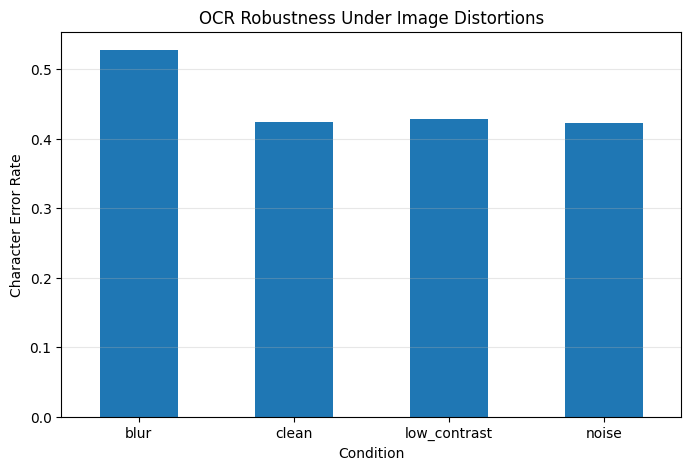

In [ ]:
import matplotlib.pyplot as plt

summary["CER"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("OCR Robustness Under Image Distortions")
plt.ylabel("Character Error Rate")
plt.xlabel("Condition")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

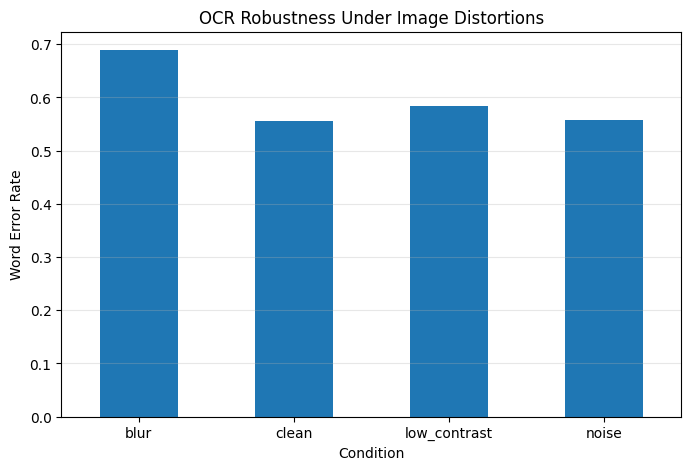

In [ ]:
summary["WER"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("OCR Robustness Under Image Distortions")
plt.ylabel("Word Error Rate")
plt.xlabel("Condition")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Add simple preprocessing

In [ ]:
def sharpen(image):

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    return cv2.filter2D(image, -1, kernel)

In [ ]:
def denoise(image):

    return cv2.fastNlMeansDenoisingColored(
        image,
        None,
        10,
        10,
        7,
        21
    )

In [ ]:
def enhance_contrast(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    return cv2.cvtColor(
        enhanced,
        cv2.COLOR_GRAY2BGR
    )

## Recovery experiment

In [ ]:
preprocessing_functions = {
    "blur": sharpen,
    "noise": denoise,
    "low_contrast": enhance_contrast
}

recovery_results = []

for image_path in selected_images:

    filename = os.path.basename(image_path)
    json_name = filename.replace(".png", ".json")

    if json_name not in annotation_map:
        continue

    gt = get_ground_truth(annotation_map[json_name])

    original = cv2.imread(image_path)

    for distortion_name, distortion_fn in distortion_functions.items():

        distorted = distortion_fn(original)

        preprocessed = preprocessing_functions[
            distortion_name
        ](distorted)

        temp_path = (
            f"/content/distorted/"
            f"processed_{distortion_name}_{filename}"
        )

        cv2.imwrite(temp_path, preprocessed)

        pred = run_ocr(temp_path)

        recovery_results.append({
            "image": filename,
            "distortion": distortion_name,
            "CER_after_preprocessing": cer(gt, pred),
            "WER_after_preprocessing": wer(gt, pred)
        })

recovery_df = pd.DataFrame(recovery_results)

recovery_summary = recovery_df.groupby(
    "distortion"
)[[
    "CER_after_preprocessing",
    "WER_after_preprocessing"
]].mean()

recovery_summary

,CER_after_preprocessing,WER_after_preprocessing
distortion,,
blur,0.456988,0.623810
low_contrast,0.425451,0.558577
noise,0.421334,0.557779


## Final Comparision

In [ ]:
final_table = summary.copy()

final_table["CER_after_preprocessing"] = \
    recovery_summary["CER_after_preprocessing"]

final_table["WER_after_preprocessing"] = \
    recovery_summary["WER_after_preprocessing"]

final_table

,CER,WER,CER_after_preprocessing,WER_after_preprocessing
distortion,,,,
blur,0.527489,0.689163,0.456988,0.623810
clean,0.423872,0.555589,NaN,NaN
low_contrast,0.427500,0.583726,0.425451,0.558577
noise,0.421684,0.557099,0.421334,0.557779


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Your experimental results
data = {
    "Distortion": ["Clean", "Blur", "Low Contrast", "Noise"],

    # Before preprocessing
    "CER": [0.423872, 0.527489, 0.427500, 0.421684],
    "WER": [0.555889, 0.689163, 0.583726, 0.557099],

    # After targeted preprocessing
    "CER_after": [np.nan, 0.456988, 0.425451, 0.421334],
    "WER_after": [np.nan, 0.623810, 0.558577, 0.557779]
}

df = pd.DataFrame(data)

df

,Distortion,CER,WER,CER_after,WER_after
0,Clean,0.423872,0.555889,NaN,NaN
1,Blur,0.527489,0.689163,0.456988,0.623810
2,Low Contrast,0.427500,0.583726,0.425451,0.558577
3,Noise,0.421684,0.557099,0.421334,0.557779


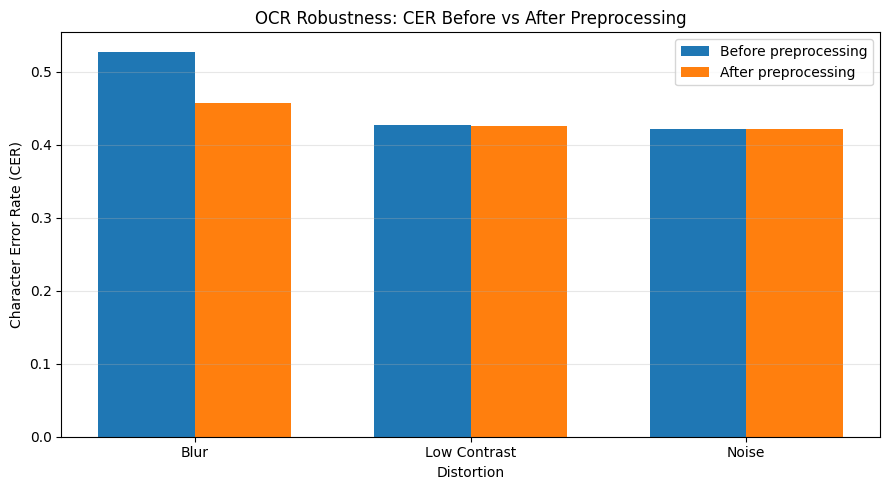

In [2]:
distortions = ["Blur", "Low Contrast", "Noise"]

before_cer = [
    0.527489,
    0.427500,
    0.421684
]

after_cer = [
    0.456988,
    0.425451,
    0.421334
]

x = np.arange(len(distortions))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    before_cer,
    width,
    label="Before preprocessing"
)

plt.bar(
    x + width/2,
    after_cer,
    width,
    label="After preprocessing"
)

plt.xlabel("Distortion")
plt.ylabel("Character Error Rate (CER)")
plt.title("OCR Robustness: CER Before vs After Preprocessing")

plt.xticks(x, distortions)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

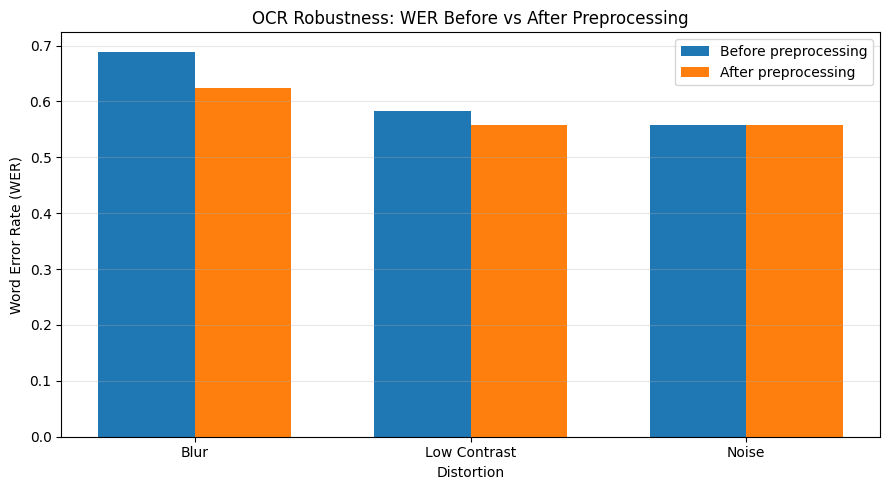

In [3]:
before_wer = [
    0.689163,
    0.583726,
    0.557099
]

after_wer = [
    0.623810,
    0.558577,
    0.557779
]

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    before_wer,
    width,
    label="Before preprocessing"
)

plt.bar(
    x + width/2,
    after_wer,
    width,
    label="After preprocessing"
)

plt.xlabel("Distortion")
plt.ylabel("Word Error Rate (WER)")
plt.title("OCR Robustness: WER Before vs After Preprocessing")

plt.xticks(x, distortions)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

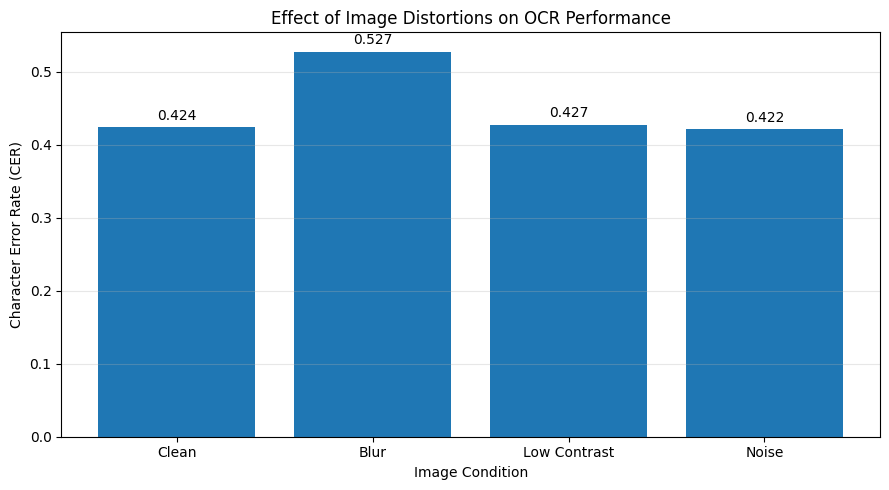

In [4]:
conditions = ["Clean", "Blur", "Low Contrast", "Noise"]

cer_values = [
    0.423872,
    0.527489,
    0.427500,
    0.421684
]

plt.figure(figsize=(9, 5))

bars = plt.bar(conditions, cer_values)

plt.xlabel("Image Condition")
plt.ylabel("Character Error Rate (CER)")
plt.title("Effect of Image Distortions on OCR Performance")

plt.grid(axis="y", alpha=0.3)

# Display values on bars
for bar, value in zip(bars, cer_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()